# Анализ данных (EDA)

**Цель**
- изучить данные
- изучить признаки
- выявить аномалии
- определить корреляции

## 1. Импорт библиотек

In [1]:
!pip install phik --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 9.9 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
import phik

## 2. Загрузка данных

In [3]:
# Чтение файла
df = pd.read_excel("/content/Данные_для_курсовои_Классическое_МО.xlsx")
print(f'В данных {df.shape[0]} наблюдений и {df.shape[1]} признаков')

# Первые 5 строк датасета
print('\nПервые 5 строк датасета:')
display(df.head())

# Удалим параметр 'unnamed:0'
df = df.drop(columns=["Unnamed: 0"])

print(f'\nПРизнаков после удаления: {df.shape[1]}')
display(df.head())

print('\nОбщая информация о признаках:\n')
df.info()

# Проверим данные на пропуски
print(f'\nНаличие пропусков в датасете всего {df.isna().sum().sum()} :\n')
print("Информация о пропусках:\n", df.isna().sum().sort_values(ascending=False).head(15))


В данных 1001 наблюдений и 214 признаков

Первые 5 строк датасета:


,Unnamed: 0,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,...,0,0,0,0,0,0,0,0,3,0
1,1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,...,0,0,0,0,0,0,0,0,3,0
2,2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,...,0,0,0,0,0,0,0,0,3,0
3,3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,...,0,0,0,0,0,0,0,0,4,0
4,4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,...,0,0,0,0,0,0,0,0,0,0



ПРизнаков после удаления: 213


,"IC50, mM","CC50, mM",SI,MaxAbsEStateIndex,MaxEStateIndex,MinAbsEStateIndex,MinEStateIndex,qed,SPS,MolWt,...,fr_sulfide,fr_sulfonamd,fr_sulfone,fr_term_acetylene,fr_tetrazole,fr_thiazole,fr_thiocyan,fr_thiophene,fr_unbrch_alkane,fr_urea
0,6.239374,175.482382,28.125000,5.094096,5.094096,0.387225,0.387225,0.417362,42.928571,384.652,...,0,0,0,0,0,0,0,0,3,0
1,0.771831,5.402819,7.000000,3.961417,3.961417,0.533868,0.533868,0.462473,45.214286,388.684,...,0,0,0,0,0,0,0,0,3,0
2,223.808778,161.142320,0.720000,2.627117,2.627117,0.543231,0.543231,0.260923,42.187500,446.808,...,0,0,0,0,0,0,0,0,3,0
3,1.705624,107.855654,63.235294,5.097360,5.097360,0.390603,0.390603,0.377846,41.862069,398.679,...,0,0,0,0,0,0,0,0,4,0
4,107.131532,139.270991,1.300000,5.150510,5.150510,0.270476,0.270476,0.429038,36.514286,466.713,...,0,0,0,0,0,0,0,0,0,0



Общая информация о признаках:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1001 entries, 0 to 1000
Columns: 213 entries, IC50, mM to fr_urea
dtypes: float64(107), int64(106)
memory usage: 1.6 MB

Наличие пропусков в датасете всего 36 :

Информация о пропусках:
 MinAbsPartialCharge    3
MaxPartialCharge       3
MinPartialCharge       3
MaxAbsPartialCharge    3
BCUT2D_MWHI            3
BCUT2D_MRLOW           3
BCUT2D_MRHI            3
BCUT2D_LOGPLOW         3
BCUT2D_LOGPHI          3
BCUT2D_CHGLO           3
BCUT2D_CHGHI           3
BCUT2D_MWLOW           3
SPS                    0
MaxEStateIndex         0
MaxAbsEStateIndex      0
dtype: int64


**Вывод:**
- Выполнена загрузка данных и их первичный осмотр:
  - Размер датасета - 1001 наблюдений и  213 признаков (после удаления неинформативного признака)
  - Данные имеют числовой (целочисленный и вещественный) тип данных
  - В данных есть пропуски в количестве 36 штук

## Обрабока пропусков

Ранее мы уже определили, что в датасете присутствую пропуски. Теперь определим их долю.

In [5]:
# Считаем долю пропусков в каждой колонке
missing_ratio = (df.isna().sum() / df.shape[0]*100).sort_values(ascending=False).head(13)
display(missing_ratio)

,0
MinAbsPartialCharge,0.2997
MaxPartialCharge,0.2997
MinPartialCharge,0.2997
MaxAbsPartialCharge,0.2997
BCUT2D_MWHI,0.2997
BCUT2D_MRLOW,0.2997
BCUT2D_MRHI,0.2997
BCUT2D_LOGPLOW,0.2997
BCUT2D_LOGPHI,0.2997
BCUT2D_CHGLO,0.2997


- Доля пропусков незначительна (менее 0,3%). Принимаем решение заменить пропуски на медианные значения признака. Медиана менее чувствительна к выбросам

In [6]:
# Заполняем пропуски медианой
df_filled = df.fillna(df.median())

print("Пропуски до заполнения:", df.isna().sum().sum())
print("Пропуски после заполнения:", df_filled.isna().sum().sum())

Пропуски до заполнения: 36
Пропуски после заполнения: 0


## 3. Анализ целевых признаков

Целевые переменные (IC50, CC50, SI) являются ключевыми для задачи, поэтому необходимо изучить их распределение.

Это позволит:
- выявить асимметрию
- обнаружить выбросы
- определить необходимость преобразований

,count,mean,std,min,25%,50%,75%,max
"IC50, mM",1001.0,222.805156,402.169734,0.003517,12.515396,46.585183,224.975928,4128.529377
"CC50, mM",1001.0,589.110728,642.867508,0.700808,99.999036,411.039342,894.089176,4538.976189
SI,1001.0,72.508823,684.482739,0.011489,1.433333,3.846154,16.566667,15620.600000


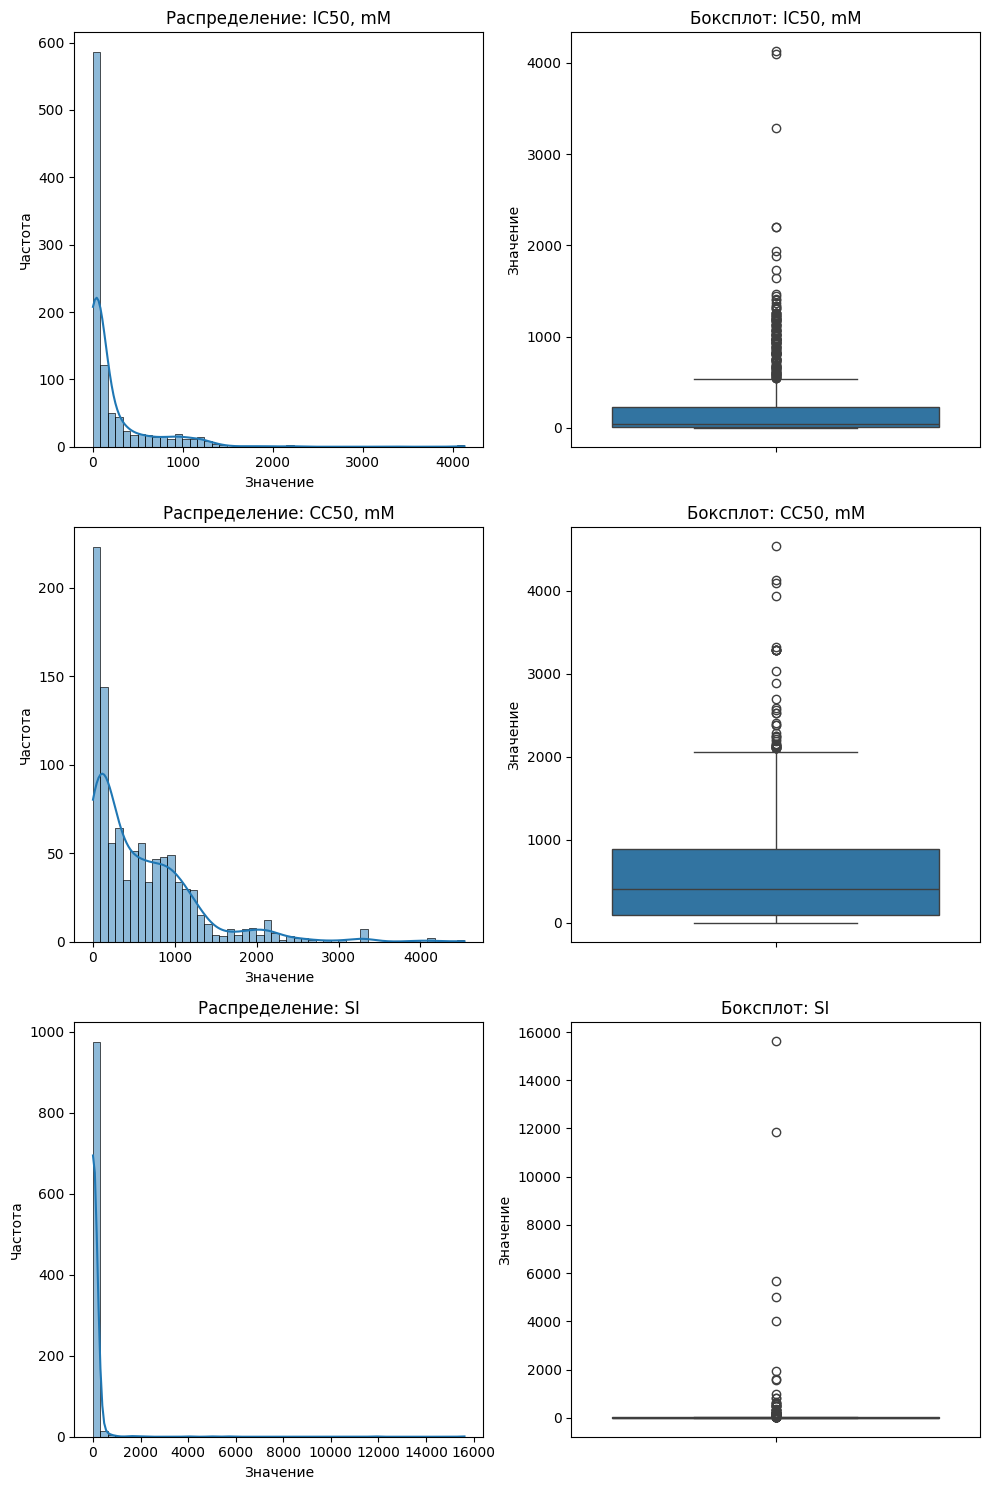

In [7]:
# Определим целевые переменные в список
targets = ['IC50, mM', 'CC50, mM', 'SI']

# Описательная статистика
display(df_filled[targets].describe().T)

n_cols = len(targets)
fig, axes = plt.subplots(n_cols, 2, figsize=(10, 5 * n_cols))

for i, col in enumerate(targets):
    # Гистограмма с KDE
    sns.histplot(df_filled[col], kde=True, ax=axes[i, 0], bins=50)
    axes[i, 0].set_title(f'Распределение: {col}')
    axes[i, 0].set_xlabel('Значение')
    axes[i, 0].set_ylabel('Частота')

    # Боксплот
    sns.boxplot(y=df_filled[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'Боксплот: {col}')
    axes[i, 1].set_ylabel('Значение')
    axes[i, 1].set_xlabel('')

plt.tight_layout()
plt.show()


Анализ распределения целевых признаков:
- распределения значений IC50, CC50 и SI имеют правостороннюю ассиметрию
- большинство значений сосредоточено в области низких значений
- боксплоты показывают выбросы и аномалии.

Для нормализации распределения часто применяется логарифмирование. В EDA оставим целевые признаки без преобразований

## Анализ и удаление сильно коррелирующих признаков

Используем phi-k корреляцию. Главное преимущество Phi-K заключается в универсальности и способности улавливать нелинейные зависимости

In [8]:
targets = ['IC50, mM', 'CC50, mM', 'SI']

# Вычисляем матрицу phi_k корреляций для всех признаков, кроме целевых
feature_cols = [col for col in df.columns if col not in targets]
phik_matrix = df[feature_cols].phik_matrix()

# Берем абсолютные значения
upper = phik_matrix.where(np.triu(np.ones(phik_matrix.shape), k=1).astype(bool))

# Выделяем признаки с корреляцией выше порога
threshold = 0.8
to_drop = []

# Проверяем, есть ли в столбце значения выше порога
for col in upper.columns:
    if (upper[col] > threshold).any():
        to_drop.append(col)

print(f"Признаки с высокой зависимостью (phi_k > {threshold}), рекомендуемые к удалению (всего {len(to_drop)}): {to_drop}")

# Удаляем их из датасета
if to_drop:
    df_cleaned = df_filled.drop(columns=to_drop)
    print(f"Размерность после удаления сильно коррелирующих признаков: {df_cleaned.shape}")
else:
    print("Признаков с зависимостью выше порога не найдено. Датасет не изменен.")
    df_cleaned = df_filled.copy()


interval columns not set, guessing: ['MaxAbsEStateIndex', 'MaxEStateIndex', 'MinAbsEStateIndex', 'MinEStateIndex', 'qed', 'SPS', 'MolWt', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'NumRadicalElectrons', 'MaxPartialCharge', 'MinPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan1', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_MWHI', 'BCUT2D_MWLOW', 'BCUT2D_CHGHI', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'BCUT2D_MRLOW', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA11', 'PEOE_VSA12', 'PEOE_VSA13', 'PEOE_VSA14', 'PEOE_VSA2', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA5', 'PEOE_VSA6', 'PEOE_VSA7', 'PEOE_VSA8', 'PEOE_VSA9', 'SMR_VSA1', 'SMR_VSA10', 'SMR_VSA2', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA6', 'SMR_VSA7', 'SMR_VSA8', 'SMR_VS

/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable NumRadicalElectrons for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable SMR_VSA8 for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable SlogP_VSA9 for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable fr_N_O for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value for variable fr_SH for analysis 1. Dropping this column
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/phik/data_quality.py:72: UserWarning: Not enough unique value 

Признаки с высокой зависимостью (phi_k > 0.8), рекомендуемые к удалению (всего 135): ['MaxEStateIndex', 'HeavyAtomMolWt', 'ExactMolWt', 'NumValenceElectrons', 'MaxPartialCharge', 'MaxAbsPartialCharge', 'MinAbsPartialCharge', 'FpDensityMorgan2', 'FpDensityMorgan3', 'BCUT2D_CHGLO', 'BCUT2D_LOGPHI', 'BCUT2D_LOGPLOW', 'BCUT2D_MRHI', 'AvgIpc', 'BalabanJ', 'BertzCT', 'Chi0', 'Chi0n', 'Chi0v', 'Chi1', 'Chi1n', 'Chi1v', 'Chi2n', 'Chi2v', 'Chi3n', 'Chi3v', 'Chi4n', 'Chi4v', 'HallKierAlpha', 'Ipc', 'Kappa1', 'Kappa2', 'Kappa3', 'LabuteASA', 'PEOE_VSA1', 'PEOE_VSA10', 'PEOE_VSA12', 'PEOE_VSA3', 'PEOE_VSA4', 'PEOE_VSA7', 'SMR_VSA1', 'SMR_VSA3', 'SMR_VSA4', 'SMR_VSA5', 'SMR_VSA7', 'SMR_VSA9', 'SlogP_VSA1', 'SlogP_VSA10', 'SlogP_VSA11', 'SlogP_VSA12', 'SlogP_VSA2', 'SlogP_VSA4', 'SlogP_VSA5', 'SlogP_VSA6', 'SlogP_VSA7', 'SlogP_VSA8', 'TPSA', 'EState_VSA1', 'EState_VSA10', 'EState_VSA2', 'EState_VSA4', 'EState_VSA5', 'EState_VSA7', 'EState_VSA8', 'VSA_EState10', 'VSA_EState2', 'VSA_EState3', 'VSA_ESt

В результате корреляционного анализа мы избавились от мультиколлинеарности

## Сохранение очищенных данных

Обработанные данные сохраняются для последующего использования при построении моделей машинного обучения.

In [9]:
df_cleaned.to_csv('cleaned_data.csv', index=False)
print("Очищенные данные сохранены в content/cleaned_data.csv")

Очищенные данные сохранены в content/cleaned_data.csv


## Выводы EDA
- Визуальный анализ показал, что целевые переменные (IC50, CC50, SI) имеют выраженную положительную асимметрию, что является типичным для химико-биологических данных.
- Параметр SI как отношения CC50 к IC50. В данных этот параметр без пропусков, соответственно его расчет не требуется.
- Анализ качества данных продемонстрировал отсутствие значимого количества пропусков. В исзодном татасете пропусков менее 0,3% для признаков с пропусками.
- Осуществлено удаление сильно коррелирующих (коллинеарных) признаков. Данный шаг направлен на снижение мультиколлинеарности и повышение стабильности и скорости обучения моделей.